In [1]:
import pandas as pd
df = pd.read_csv("E:\\7. Projects From Sem 3\\Deep learning\\ANN\\Introduction\\data\\Churn_Modelling.csv")

In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
experiment =df[["Geography","Gender"]]

In [6]:
pd.get_dummies(experiment,columns=["Geography","Gender"], drop_first=True)

,Geography_Germany,Geography_Spain,Gender_Male
0,False,False,False
1,False,True,False
2,False,False,False
3,False,False,False
4,False,True,False
...,...,...,...
9995,False,False,True
9996,False,False,True
9997,False,False,False
9998,True,False,True


In [7]:
pd.get_dummies(df,columns=["Geography","Gender"], drop_first=True)

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [8]:
df = pd.get_dummies(df,columns=["Geography","Gender"], drop_first=True)

In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [10]:
df.shape

(10000, 15)

In [11]:
X = df.drop("Exited", axis=1)
X.shape

(10000, 14)

In [12]:
y= df["Exited"].values
y.shape

(10000,)

In [13]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [14]:
X_train

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7389,7390,15676909,Mishin,667,34,5,0.00,2,1,0,163830.64,False,True,False
9275,9276,15749265,Carslaw,427,42,1,75681.52,1,1,1,57098.00,True,False,True
2995,2996,15582492,Moore,535,29,2,112367.34,1,1,0,185630.76,False,False,False
5316,5317,15780386,Ferri,654,40,5,105683.63,1,1,0,173617.09,False,True,True
356,357,15611759,Simmons,850,57,8,126776.30,2,1,1,132298.49,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,9226,15584928,Ugochukwutubelum,594,32,4,120074.97,2,1,1,162961.79,True,False,False
4859,4860,15647111,White,794,22,4,114440.24,1,1,1,107753.07,False,True,False
3264,3265,15574372,Hoolan,738,35,5,161274.05,2,1,0,181429.87,False,False,True
9845,9846,15664035,Parsons,590,38,9,0.00,2,1,1,148750.16,False,True,False


In [15]:
X_test

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9394,9395,15615753,Upchurch,597,35,8,131101.04,1,1,1,192852.67,True,False,False
898,899,15654700,Fallaci,523,40,2,102967.41,1,1,0,128702.10,False,False,False
2398,2399,15633877,Morrison,706,42,8,95386.82,1,1,1,75732.25,False,True,False
5906,5907,15745623,Worsnop,788,32,4,112079.58,1,0,0,89368.59,False,False,True
2343,2344,15765902,Gibson,706,38,5,163034.82,2,1,1,135662.17,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,1038,15631054,Volkova,625,24,1,0.00,2,1,1,180969.55,False,False,False
2899,2900,15810944,Bryant,586,35,7,0.00,2,1,0,70760.69,False,False,False
9549,9550,15772604,Chiemezie,578,36,1,157267.95,2,1,0,141533.19,False,True,True
2740,2741,15787699,Burke,650,34,4,142393.11,1,1,1,11276.48,True,False,True


In [16]:
y_train

array([0, 0, 0, ..., 0, 0, 1], shape=(8000,))

In [17]:
y_test

array([0, 1, 0, ..., 0, 0, 0], shape=(2000,))

In [50]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [51]:
model = Sequential()

In [52]:
model.add(Dense(11,activation="relu",input_dim=11))
# model.add(Dense(11,activation="relu")) this is for an even deeper network
model.add(Dense(1,activation="sigmoid"))

e:\7. Projects From Sem 3\Deep learning\env\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144 (576.00 B)

 Trainable params: 144 (576.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(optimizer='Adam',loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
x_train = X.drop(columns=["RowNumber","RowNumber","Surname"])

In [44]:
x_train.dtypes

CustomerId             int64
CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object

In [48]:
x_train.drop(columns=["CustomerId"],inplace=True)

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [58]:
X_test.drop(columns=["CustomerId","RowNumber","Surname"],inplace=True)

In [59]:
x_train_trf = scaler.fit_transform(x_train)
x_test_trf = scaler.transform(X_test)

In [63]:
print(x_train_trf.shape)
print(x_test_trf.shape)
print(y_test.shape)
print(y_train.shape)

(10000, 11)
(2000, 11)
(2000,)
(8000,)


In [65]:
history = model.fit(x_train_trf[8000:],y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7619 - loss: 0.5507 - val_accuracy: 0.7825 - val_loss: 0.5389
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7650 - loss: 0.5482 - val_accuracy: 0.7850 - val_loss: 0.5374
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.5459 - val_accuracy: 0.7825 - val_loss: 0.5358
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.5437 - val_accuracy: 0.7825 - val_loss: 0.5346
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7656 - loss: 0.5419 - val_accuracy: 0.7850 - val_loss: 0.5333
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.5400 - val_accuracy: 0.7850 - val_loss: 0.5324
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7675 - loss: 0.5385 - val_accuracy: 0.7825 - val_loss: 0.5316
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7681 - loss: 0.5368 - val_accuracy: 0.7825 - v

In [68]:
y_pred_see=model.predict(x_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [69]:
y_pred_see

array([[0.20607531],
       [0.2861286 ],
       [0.12890711],
       ...,
       [0.08439039],
       [0.27028337],
       [0.33111924]], shape=(2000, 1), dtype=float32)

In [71]:
y_pred_2 = y_pred_see.argmax(axis=-1)

In [ ]:
y_pred = model.predict(x_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [72]:
y_pred_2

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [73]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_2)

0.7975

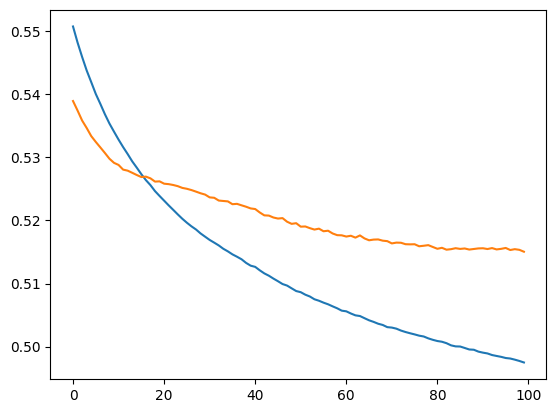

In [74]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

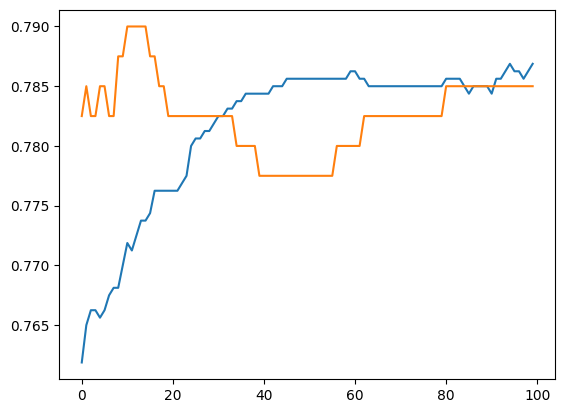

In [75]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])